In [ ]:
# ============================================================
# PREDICCIÓN DE SALARIO BASADA EN TEXTO - Luis Jose Gonzalez Montilla
# ============================================================

!pip install -q datasets sentence-transformers scikit-learn matplotlib seaborn joblib

import os, time, gc, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.svm import SVR

from datasets import load_dataset
from sentence_transformers import SentenceTransformer

sns.set(style="whitegrid")

# ============================================================
# 1) Configuración de datasets
# ============================================================
TRAIN_DATASET = "datastax/linkedin_job_listings"
TEST_DATASET  = "xanderios/linkedin-job-postings"

# ============================================================
# 2) Modelos y embeddings
# ============================================================
EMBEDDERS = {
    "all-MiniLM-L6-v2": SentenceTransformer("all-MiniLM-L6-v2"),
    "paraphrase-MiniLM-L6-v2": SentenceTransformer("paraphrase-MiniLM-L6-v2"),
    "all-mpnet-base-v2": SentenceTransformer("all-mpnet-base-v2"),
}

REGRESSORS = {
    "KNN": KNeighborsRegressor(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=300, random_state=42),
    "LinearRegression": LinearRegression(),
    "SGD": SGDRegressor(max_iter=2000, tol=1e-3, random_state=42),
    "SVR": SVR(),
}

METRICS = {
    "MSE": mean_squared_error,
    "MAE": mean_absolute_error,
    "R2": r2_score,
}

RESULTS = []

# ============================================================
# 3) Funciones de limpieza y carga (2000 muestras)
# ============================================================
def clean_salary(df):
    """Normaliza salario a USD anual según pay_period"""
    min_s = pd.to_numeric(df.get("min_salary"), errors="coerce")
    max_s = pd.to_numeric(df.get("max_salary"), errors="coerce")

    df["salary"] = np.where(
        (~min_s.isna()) & (~max_s.isna()),
        (min_s + max_s)/2,
        np.nan
    )

    if "pay_period" in df.columns:
        df["pay_period"] = df["pay_period"].str.lower()
        df.loc[df["pay_period"].str.contains("year", na=False), "salary"] *= 1
        df.loc[df["pay_period"].str.contains("month", na=False), "salary"] *= 12
        df.loc[df["pay_period"].str.contains("week", na=False), "salary"] *= 52
        df.loc[df["pay_period"].str.contains("hour", na=False), "salary"] *= 40*52

    df = df.dropna(subset=["salary"])

    if "description" in df.columns:
        df = df[df["description"].str.len() > 20]

    if len(df) > 0:
        low, high = np.percentile(df["salary"], [1,99])
        df = df[(df["salary"] >= low) & (df["salary"] <= high)]

    return df.reset_index(drop=True)

def load_and_clean_train(name, n_samples=2000):
    ds = load_dataset(name, split="train", trust_remote_code=True)
    df = pd.DataFrame(ds)
    df = clean_salary(df)
    return df.sample(min(n_samples, len(df)), random_state=42).reset_index(drop=True)

def load_and_clean_test(name, n_samples=2000):
    ds = load_dataset(name, split="train", trust_remote_code=True)
    df = pd.DataFrame(ds)
    df = clean_salary(df)
    return df.sample(min(n_samples, len(df)), random_state=42).reset_index(drop=True)

# ============================================================
# 4) Carga datos
# ============================================================
print("Cargando datos de entrenamiento ...")
df_train = load_and_clean_train(TRAIN_DATASET)
print("Cargando datos de testeo ...")
df_test = load_and_clean_test(TEST_DATASET)
print(f"Train size: {len(df_train)}, Test size: {len(df_test)}")

# Log-transform del target
y_train = np.log1p(df_train["salary"].values)
y_test  = np.log1p(df_test["salary"].values)

# ============================================================
# 5) Funciones de embeddings y evaluación
# ============================================================
def embed_texts(texts, model):
    emb = model.encode(texts, show_progress_bar=True, convert_to_numpy=True)
    return np.nan_to_num(emb, nan=0.0)

def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_te)
    infer_time = time.time() - start

    scores = {m: fn(y_te, y_pred) for m, fn in METRICS.items()}
    return scores, train_time, infer_time, y_pred

# ============================================================
# 6) Entrenamiento de todos los modelos
# ============================================================
for emb_name, emb_model in EMBEDDERS.items():
    print(f"\nVectorizando con {emb_name} ...")

    X_train_emb = embed_texts(df_train["description"].tolist(), emb_model)
    X_test_emb  = embed_texts(df_test["description"].tolist(), emb_model)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_emb)
    X_test_scaled  = scaler.transform(X_test_emb)

    pca = PCA(n_components=min(50, X_train_scaled.shape[1]))
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca  = pca.transform(X_test_scaled)

    joblib.dump(scaler, f"/content/{emb_name}_scaler.joblib")
    joblib.dump(pca, f"/content/{emb_name}_pca.joblib")

    for model_name, reg in REGRESSORS.items():
        print(f"Entrenando {model_name} ...")
        stats, t_train, t_infer, y_pred = evaluate_model(
            reg, X_train_pca, y_train, X_test_pca, y_test
        )
        joblib.dump(reg, f"/content/{emb_name}_{model_name}.joblib")
        size_mb = os.path.getsize(f"/content/{emb_name}_{model_name}.joblib")/(1024**2)
        RESULTS.append({
            "embedder": emb_name,
            "model": model_name,
            "MSE": stats["MSE"],
            "MAE": stats["MAE"],
            "R2": stats["R2"],
            "train_time": t_train,
            "infer_time": t_infer,
            "model_size_mb": size_mb
        })
        del reg
        gc.collect()

# ============================================================
# 7) Benchmark resultados
# ============================================================
df_res = pd.DataFrame(RESULTS)
df_res.to_csv("/content/benchmark_linkedin_salary.csv", index=False)
print(df_res)

# ============================================================
# 8) Función de prueba manual
# ============================================================
def predict_salary(text, emb_name, model_name):
    emb_model = EMBEDDERS[emb_name]
    scaler = joblib.load(f"/content/{emb_name}_scaler.joblib")
    pca    = joblib.load(f"/content/{emb_name}_pca.joblib")
    reg    = joblib.load(f"/content/{emb_name}_{model_name}.joblib")

    X_emb = embed_texts([text], emb_model)
    X_scaled = scaler.transform(X_emb)
    X_pca    = pca.transform(X_scaled)

    y_pred_log = reg.predict(X_pca)
    return float(np.expm1(y_pred_log[0]))

# ============================================================
# 9) Benchmark cualitativo de ejemplo
# ============================================================
texto_ejemplo = "Software engineer con 5 años de experiencia en Python y Machine Learning"

print("\nBENCHMARK CUALITATIVO EJEMPLO:\n")
line = "-"*80
print(line)
print(f"{'Modelo':20} | {'Predicción anual USD':>25}")
print(line)
for emb_name in EMBEDDERS:
    for model_name in REGRESSORS:
        try:
            pred = predict_salary(texto_ejemplo, emb_name, model_name)
            print(f"{model_name:20} | {pred:25,.2f}")
        except:
            print(f"{model_name:20} | {'ERROR':>25}")
print(line)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

LinearRegression     |                 92,187.53


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

SGD                  |                 77,900.86


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

SVR                  |                110,889.14
--------------------------------------------------------------------------------


In [ ]:
# Supongamos que ya cargaste el dataset de entrenamiento como df_train
# df_train debe tener la columna 'salary'

# Definir salario mínimo
SALARIO_MINIMO = 20000

# Filtrar dataset
df_filtrado = df_train[df_train['salary'] >= SALARIO_MINIMO]

# Estadísticas descriptivas del dataset filtrado
stats = df_filtrado['salary'].describe()

# Crear tabla de texto
tabla = f"""
==========================================
RESUMEN ESTADÍSTICO DE SALARIOS (>= ${SALARIO_MINIMO})
==========================================
Cantidad de muestras  : {int(stats['count'])}
Salario mínimo        : ${stats['min']:.2f}
Salario máximo        : ${stats['max']:.2f}
Salario medio         : ${stats['mean']:.2f}
Desviación estándar   : ${stats['std']:.2f}
Mediana (50%)         : ${stats['50%']:.2f}
Percentil 25%         : ${stats['25%']:.2f}
Percentil 75%         : ${stats['75%']:.2f}
==========================================
"""

print(tabla)


RESUMEN ESTADÍSTICO DE SALARIOS (>= $20000)
Cantidad de muestras  : 1993
Salario mínimo        : $22360.00
Salario máximo        : $308000.00
Salario medio         : $99839.96
Desviación estándar   : $51043.91
Mediana (50%)         : $89910.00
Percentil 25%         : $59719.00
Percentil 75%         : $130000.00



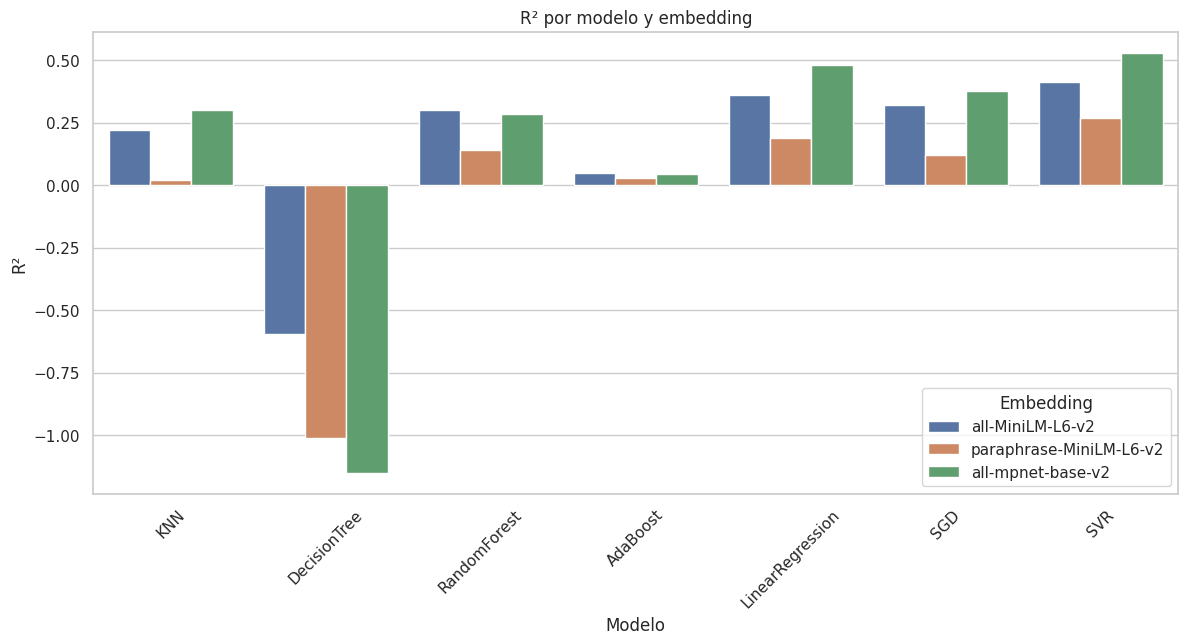

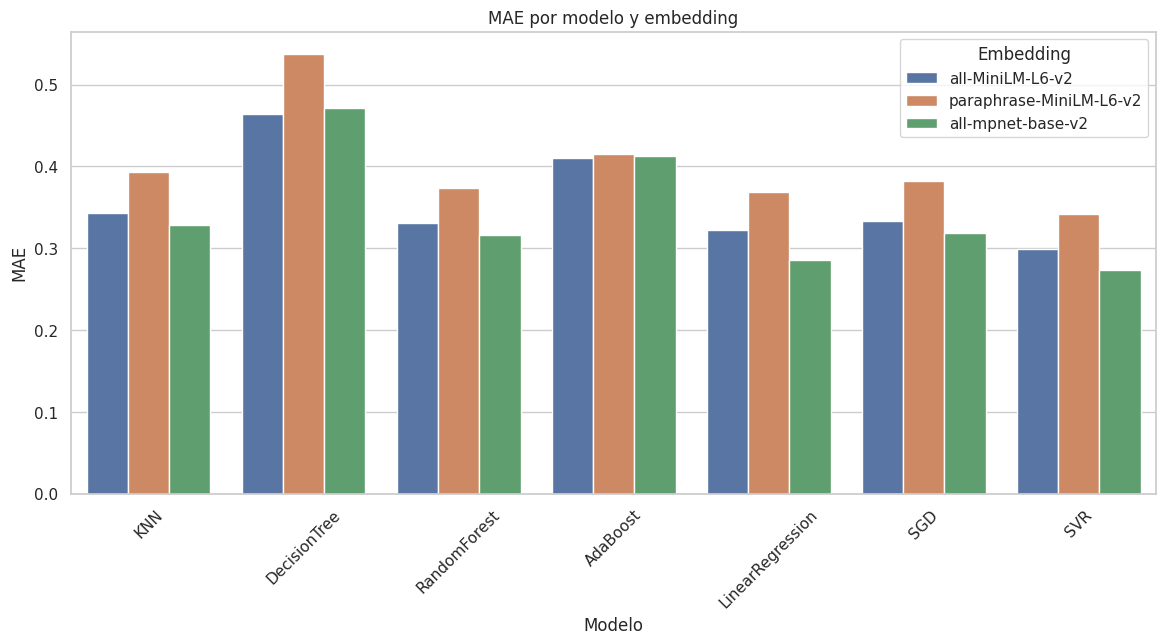

In [ ]:
# ============================================================
# 1) Configuración estética
# ============================================================
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

# ============================================================
# 2) R² por modelo y embedding
# ============================================================
plt.figure(figsize=(14,6))
sns.barplot(data=df_res, x="model", y="R2", hue="embedder")
plt.title("R² por modelo y embedding")
plt.ylabel("R²")
plt.xlabel("Modelo")
plt.xticks(rotation=45)
plt.legend(title="Embedding")
plt.show()

# ============================================================
# 3) MAE por modelo y embedding
# ============================================================
plt.figure(figsize=(14,6))
sns.barplot(data=df_res, x="model", y="MAE", hue="embedder")
plt.title("MAE por modelo y embedding")
plt.ylabel("MAE")
plt.xlabel("Modelo")
plt.xticks(rotation=45)
plt.legend(title="Embedding")
plt.show()

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

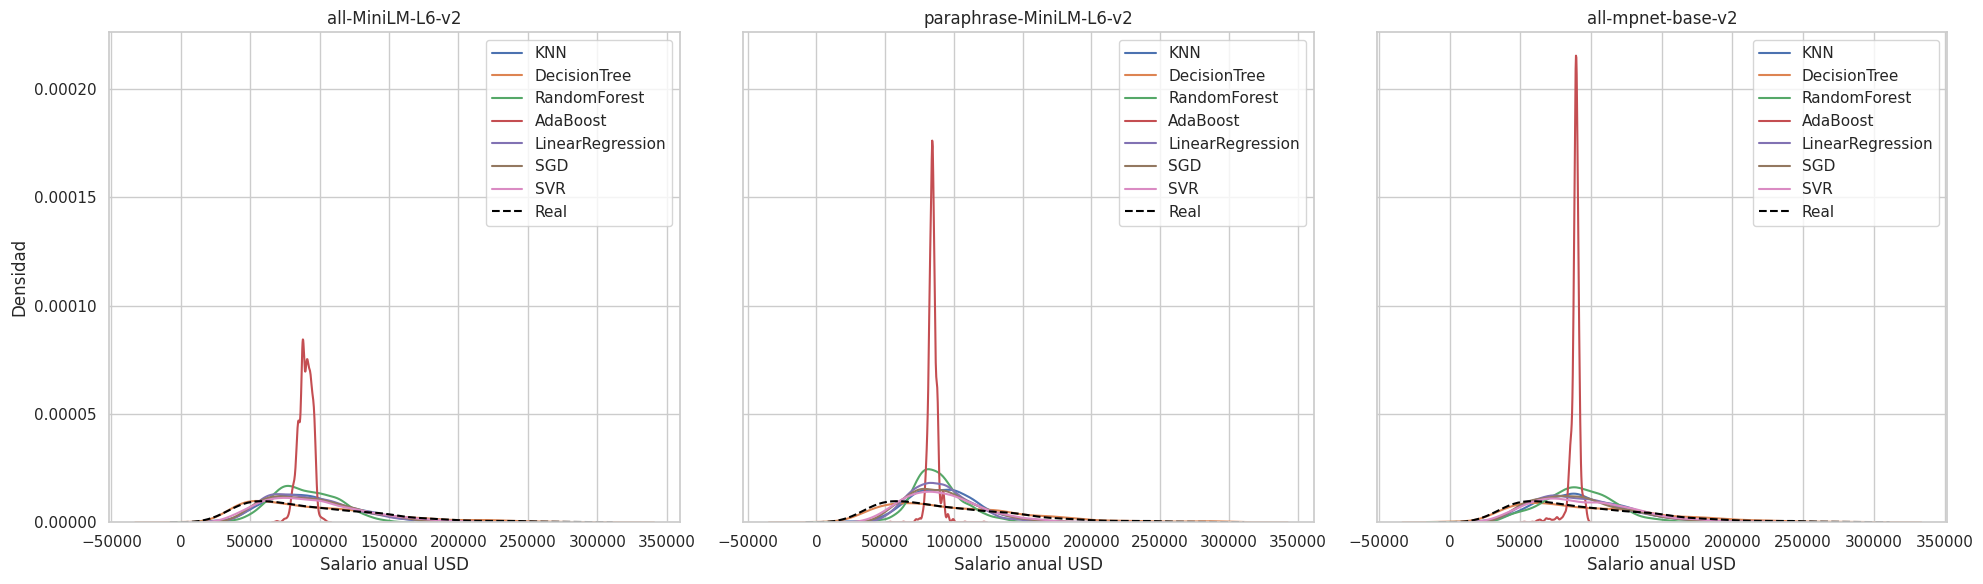

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
from sentence_transformers import SentenceTransformer

embedding_list = ["all-MiniLM-L6-v2", "paraphrase-MiniLM-L6-v2", "all-mpnet-base-v2"]
model_list     = ["KNN", "DecisionTree", "RandomForest", "AdaBoost", "LinearRegression", "SGD", "SVR"]

fig, axes = plt.subplots(1, len(embedding_list), figsize=(20,6), sharey=True)

for i, emb_name in enumerate(embedding_list):
    emb_model = SentenceTransformer(emb_name)
    X_test_emb = embed_texts(df_test["description"].tolist(), emb_model)

    for model_name in model_list:
        try:
            scaler = joblib.load(f"/content/{emb_name}_scaler.joblib")
            pca    = joblib.load(f"/content/{emb_name}_pca.joblib")
            reg    = joblib.load(f"/content/{emb_name}_{model_name}.joblib")

            X_test_scaled = scaler.transform(X_test_emb)
            X_test_pca    = pca.transform(X_test_scaled)
            y_pred_log    = reg.predict(X_test_pca)
            y_pred        = np.expm1(y_pred_log)

            sns.kdeplot(y_pred, ax=axes[i], label=model_name)
        except:
            pass

    sns.kdeplot(np.expm1(y_test), color="black", linestyle="--", ax=axes[i], label="Real")
    axes[i].set_title(emb_name)
    axes[i].set_xlabel("Salario anual USD")
    if i == 0:
        axes[i].set_ylabel("Densidad")
    axes[i].legend()

plt.tight_layout()
plt.show()


In [ ]:
# =========================================
# PREDICCIÓN INTERACTIVA DE SALARIO
# =========================================

import joblib
import numpy as np
from sentence_transformers import SentenceTransformer

# --- Configuración de embeddings y modelos disponibles ---
EMBEDDERS = [
    "all-MiniLM-L6-v2",
    "paraphrase-MiniLM-L6-v2",
    "all-mpnet-base-v2"
]

MODELS = [
    "KNN",
    "DecisionTree",
    "RandomForest",
    "AdaBoost",
    "LinearRegression",
    "SGD",
    "SVR"
]

def predict_salary(text, emb_name, model_name):
    """
    Predice el salario dado un texto de descripción de empleo
    usando un embedding y modelo previamente entrenado.
    """
    # Cargar embedding
    emb_model = SentenceTransformer(emb_name)

    # Cargar modelo, scaler y PCA
    reg = joblib.load(f"/content/{emb_name}_{model_name}.joblib")
    scaler = joblib.load(f"/content/{emb_name}_scaler.joblib")
    pca = joblib.load(f"/content/{emb_name}_pca.joblib")

    # Transformar el texto
    X_emb = emb_model.encode([text], convert_to_numpy=True)
    X_scaled = scaler.transform(X_emb)
    X_pca = pca.transform(X_scaled)

    # Predecir
    log_salary = reg.predict(X_pca)
    salary = np.expm1(log_salary)
    return salary[0]

# --- Interfaz interactiva ---
while True:
    print("\n=== PREDICCIÓN DE SALARIO ===")
    print("Embeddings disponibles:", ", ".join(EMBEDDERS))
    emb_sel = input("Selecciona embedding: ").strip()
    if emb_sel not in EMBEDDERS:
        print("Embedding inválido, intenta de nuevo.")
        continue

    print("Modelos disponibles:", ", ".join(MODELS))
    model_sel = input("Selecciona modelo: ").strip()
    if model_sel not in MODELS:
        print("Modelo inválido, intenta de nuevo.")
        continue

    texto = input("Introduce descripción de empleo: ").strip()
    if len(texto) < 10:
        print("Texto demasiado corto, intenta de nuevo.")
        continue

    try:
        salario_pred = predict_salary(texto, emb_sel, model_sel)
        print(f"\nPredicción de salario usando {emb_sel} + {model_sel}: ${salario_pred:,.2f}")
    except FileNotFoundError:
        print("ERROR: No se encontraron los archivos de modelo/scaler/PCA. Asegúrate de haber entrenado y guardado los modelos.")

    otra = input("\n¿Deseas hacer otra predicción? (s/n): ").strip().lower()
    if otra != "s":
        break



=== PREDICCIÓN DE SALARIO ===
Embeddings disponibles: all-MiniLM-L6-v2, paraphrase-MiniLM-L6-v2, all-mpnet-base-v2
Selecciona embedding: paraphrase-MiniLM-L6-v2
Modelos disponibles: KNN, DecisionTree, RandomForest, AdaBoost, LinearRegression, SGD, SVR
Selecciona modelo: RandomForest
Introduce descripción de empleo: Software engineer con 5 años de experiencia en Python y Machine Learning

Predicción de salario usando paraphrase-MiniLM-L6-v2 + RandomForest: $90,165.00

¿Deseas hacer otra predicción? (s/n): n


In [ ]:
# -----------------------------
# Configuración
# -----------------------------
EMBEDDINGS = [
    "all-MiniLM-L6-v2",
    "paraphrase-MiniLM-L6-v2",
    "all-mpnet-base-v2"
]

MODELOS = [
    "KNN", "DecisionTree", "RandomForest", "AdaBoost",
    "LinearRegression", "SGD", "SVR"
]

texto_ejemplo = "Software engineer con 5 años de experiencia en Python y Machine Learning"

# -----------------------------
# Función para predecir salario
# -----------------------------
def predict_salary(texto, embedding_name, modelo_name):
    try:
        # Cargar embedding
        model_emb = SentenceTransformer(embedding_name)
        emb = model_emb.encode([texto], convert_to_numpy=True)

        # Cargar scaler y PCA
        scaler = joblib.load(f"/content/{embedding_name}_scaler.joblib")
        pca = joblib.load(f"/content/{embedding_name}_pca.joblib")
        emb_scaled = scaler.transform(emb)
        emb_pca = pca.transform(emb_scaled)

        # Cargar modelo
        model = joblib.load(f"/content/{embedding_name}_{modelo_name}.joblib")

        pred_log = model.predict(emb_pca)
        pred = np.expm1(pred_log)  # Inversa del log1p usado en entrenamiento
        return pred[0]
    except Exception as e:
        return f"ERROR: {e}"

# -----------------------------
# Generar tabla de predicciones
# -----------------------------
# Determinar ancho de columnas
col_width_emb = max(len(e) for e in EMBEDDINGS) + 4
col_width_mod = max(len(m) for m in MODELOS) + 4
col_width_pred = 15

# Crear separadores
sep_line = "+" + "-"*col_width_emb + "+" + "-"*col_width_mod + "+" + "-"*col_width_pred + "+"

# Encabezado
header = f"| {'Embedding'.ljust(col_width_emb-1)}| {'Modelo'.ljust(col_width_mod-1)}| {'Predicción'.ljust(col_width_pred-1)}|"

print(sep_line)
print(header)
print(sep_line)

# Llenar tabla
for emb in EMBEDDINGS:
    for mod in MODELOS:
        pred = predict_salary(texto_ejemplo, emb, mod)
        if isinstance(pred, float):
            pred_str = f"${pred:,.2f}"
        else:
            pred_str = str(pred)
        print(f"| {emb.ljust(col_width_emb-1)}| {mod.ljust(col_width_mod-1)}| {pred_str.ljust(col_width_pred-1)}|")
    print(sep_line)

print("\nTexto usado para las predicciones:")
print(texto_ejemplo)

+---------------------------+--------------------+---------------+
| Embedding                 | Modelo             | Predicción    |
+---------------------------+--------------------+---------------+
| all-MiniLM-L6-v2          | KNN                | $141,736.51   |
| all-MiniLM-L6-v2          | DecisionTree       | $130,000.00   |
| all-MiniLM-L6-v2          | RandomForest       | $121,386.88   |
| all-MiniLM-L6-v2          | AdaBoost           | $87,978.21    |
| all-MiniLM-L6-v2          | LinearRegression   | 135008.94     |
| all-MiniLM-L6-v2          | SGD                | $130,418.06   |
| all-MiniLM-L6-v2          | SVR                | $146,441.20   |
+---------------------------+--------------------+---------------+
| paraphrase-MiniLM-L6-v2   | KNN                | $146,634.05   |
| paraphrase-MiniLM-L6-v2   | DecisionTree       | $93,600.00    |
| paraphrase-MiniLM-L6-v2   | RandomForest       | $90,165.00    |
| paraphrase-MiniLM-L6-v2   | AdaBoost           | $85,327.00 

In [ ]:
# -----------------------------
# Configuración
# -----------------------------
EMBEDDINGS = [
    "all-MiniLM-L6-v2",
    "paraphrase-MiniLM-L6-v2",
    "all-mpnet-base-v2"
]

MODELOS = [
    "KNN", "DecisionTree", "RandomForest", "AdaBoost",
    "LinearRegression", "SGD", "SVR"
]

texto_ejemplo = "Ciber Security con 5 años de experiencia"

# -----------------------------
# Función para predecir salario
# -----------------------------
def predict_salary(texto, embedding_name, modelo_name):
    try:
        # Cargar embedding
        model_emb = SentenceTransformer(embedding_name)
        emb = model_emb.encode([texto], convert_to_numpy=True)

        # Cargar scaler y PCA
        scaler = joblib.load(f"/content/{embedding_name}_scaler.joblib")
        pca = joblib.load(f"/content/{embedding_name}_pca.joblib")
        emb_scaled = scaler.transform(emb)
        emb_pca = pca.transform(emb_scaled)

        # Cargar modelo
        model = joblib.load(f"/content/{embedding_name}_{modelo_name}.joblib")

        pred_log = model.predict(emb_pca)
        pred = np.expm1(pred_log)
        return pred[0]
    except Exception as e:
        return f"ERROR: {e}"

# -----------------------------
# Generar tabla de predicciones
# -----------------------------
# Determinar ancho de columnas
col_width_emb = max(len(e) for e in EMBEDDINGS) + 4
col_width_mod = max(len(m) for m in MODELOS) + 4
col_width_pred = 15

# Crear separadores
sep_line = "+" + "-"*col_width_emb + "+" + "-"*col_width_mod + "+" + "-"*col_width_pred + "+"

# Encabezado
header = f"| {'Embedding'.ljust(col_width_emb-1)}| {'Modelo'.ljust(col_width_mod-1)}| {'Predicción'.ljust(col_width_pred-1)}|"

print(sep_line)
print(header)
print(sep_line)

# Llenar tabla
for emb in EMBEDDINGS:
    for mod in MODELOS:
        pred = predict_salary(texto_ejemplo, emb, mod)
        if isinstance(pred, float):
            pred_str = f"${pred:,.2f}"
        else:
            pred_str = str(pred)
        print(f"| {emb.ljust(col_width_emb-1)}| {mod.ljust(col_width_mod-1)}| {pred_str.ljust(col_width_pred-1)}|")
    print(sep_line)

# Texto de ejemplo al final
print("\nTexto usado para las predicciones:")
print(texto_ejemplo)